## Name: Aaseem Ashfaq Mhaskar

## Roll no: 1

# About the project:

This project implements a **CycleGAN-based deep learning model** to translate football player performance statistics between two different leagues: the **Premier League** and **Ligue 1**. Instead of generating data from random noise like a traditional GAN, the model learns relationships between two domains of player statistics and predicts how a player’s performance might change when moving from one league to another. The architecture consists of **two generators and two discriminators**, where one generator converts Ligue 1 statistics to Premier League–like statistics and the other performs the reverse transformation. The discriminators evaluate whether the generated statistics look realistic compared to actual player data from each league. The model is trained using **adversarial loss, cycle consistency loss, and identity loss**, ensuring that translated statistics remain realistic while preserving the original player characteristics. This approach demonstrates how **Generative Adversarial Networks (GANs)** can be applied beyond image generation to tasks like **sports analytics, player transfer analysis, and performance prediction across leagues**.


In [4]:
# ── Install dependencies ──────────────────────────────────────────
!pip install torch scikit-learn joblib scipy matplotlib seaborn -q

# ── Imports ───────────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

from google.colab import files

print("PyTorch version :", torch.__version__)
print("GPU available   :", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device    :", device)

PyTorch version : 2.10.0+cu128
GPU available   : True
Using device    : cuda


In [5]:
# ── 2A. Upload all 7 CSV files ────────────────────────────────────
print("Select all 7 cleaned_XXXX-XX.csv files...")
uploaded = files.upload()

# ── 2B. Load and combine ─────────────────────────────────────────
dfs = []
for filename in sorted(uploaded.keys()):
    df = pd.read_csv(filename, encoding="latin-1")
    df["season_file"] = filename
    dfs.append(df)
    print(f"  Loaded {filename} → {len(df)} rows")

raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal combined rows: {len(raw)}")
print("Columns found:", raw.columns.tolist())
print("Leagues found:", raw["Comp"].unique() if "Comp" in raw.columns else "No Comp column")

Select all 7 cleaned_XXXX-XX.csv files...


Saving cleaned_2017-18.csv to cleaned_2017-18.csv
Saving cleaned_2018-19.csv to cleaned_2018-19.csv
Saving cleaned_2019-20.csv to cleaned_2019-20.csv
Saving cleaned_2020-21.csv to cleaned_2020-21.csv
Saving cleaned_2021-22.csv to cleaned_2021-22.csv
Saving cleaned_2022-23.csv to cleaned_2022-23.csv
Saving cleaned_2023-24.csv to cleaned_2023-24.csv
  Loaded cleaned_2017-18.csv → 2549 rows
  Loaded cleaned_2018-19.csv → 2503 rows
  Loaded cleaned_2019-20.csv → 2558 rows
  Loaded cleaned_2020-21.csv → 2634 rows
  Loaded cleaned_2021-22.csv → 2689 rows
  Loaded cleaned_2022-23.csv → 2687 rows
  Loaded cleaned_2023-24.csv → 2623 rows

Total combined rows: 18243
Columns found: ['rk', 'player', 'nation', 'pos', 'squad', 'comp', 'age', 'born', 'Matches Played', 'Avg Mins per Match', 'Goals', 'Assists', 'Goals & Assists', 'Non Penalty Goals', 'Penalty Kicks Made', 'Expected Goals', 'Exp NPG', 'Progressive Carries', 'Progressive Passes', 'Goals p 90', 'Assists p 90', 'Tackles attempted', 'Tackle

In [6]:
import pandas as pd

# Just load one file to check structure
df = pd.read_csv("cleaned_2022-23.csv")

print("SHAPE:", df.shape)
print("\nCOLUMNS:")
print(df.columns.tolist())
print("\nLEAGUES:")
print(df["Comp"].unique() if "Comp" in df.columns else df.iloc[:, 0].unique())
print("\nFIRST 3 ROWS:")
df.head(3)

SHAPE: (2687, 65)

COLUMNS:
['rk', 'player', 'nation', 'pos', 'squad', 'comp', 'age', 'born', 'Matches Played', 'Avg Mins per Match', 'Goals', 'Assists', 'Goals & Assists', 'Non Penalty Goals', 'Penalty Kicks Made', 'Expected Goals', 'Exp NPG', 'Progressive Carries', 'Progressive Passes', 'Goals p 90', 'Assists p 90', 'Tackles attempted', 'Tackles Won', '% Dribbles tackled', 'Shots blocked', 'Passes blocked', 'Interceptions', 'Clearances', 'Errors made', 'Goals Against', 'Goals against p 90', 'Saves', 'Saves %', 'Clean Sheets', '% Clean sheets', '% Penalty saves', 'Passes Completed', 'Passes Attempted', 'Pass completion %', 'Progressive passes distance', '% Short pass completed', '% Medium passes completed', '% Long passes completed', 'Key passes', '1/3', 'Passes into penalty area', 'touches_def_pen', 'Take ons attempted', '% Successful take-ons', 'Times tackled during take-on', 'carries_prgc', 'carries final 3rd', 'carries penalty area', 'Possessions lost', 'Goals Scored', 'Total Shot

,rk,player,nation,pos,squad,comp,age,born,Matches Played,Avg Mins per Match,...,Total Shots,% Shots on target,Shots p 90,Goals per shot,Goals per shot on target,% Aerial Duels won,Shot creating actions p 90,Goal creating actions p 90,Crosses Stopped,season
0,1,Brenden Aaronson,United States,MF,Leeds United,Premier League,21,2000,36,2372,...,41,22.0,0.34,0.02,0.11,17.0,3.60,0.27,0.0,2022-2023
1,2,Paxten Aaronson,United States,MF,Eint Frankfurt,Bundesliga,18,2003,7,173,...,4,25.0,0.52,0.00,0.00,50.0,4.16,1.04,0.0,2022-2023
2,3,James Abankwah,Ireland,DF,Udinese,Serie A,18,2004,2,63,...,0,0.0,0.00,0.00,0.00,100.0,0.00,0.00,0.0,2022-2023


# 2D. Filter leagues and minimum minutes
This code filters the dataset to include only players who have played at least 5 matches, ensuring reliable statistics. It then separates players from the Premier League and Ligue 1 using boolean masks. Rows with missing values in the selected features are removed, and the cleaned feature data is stored in pl_df and l1_df for model training. Player information such as name, team, and season is stored separately, and the final number of players in each league is printed.

In [10]:
# ── 2D. Filter leagues and minimum minutes ────────────────────────
raw_filtered = raw[raw["Matches Played"] >= 5].copy()

pl_mask = raw_filtered["comp"] == "Premier League"
l1_mask = raw_filtered["comp"] == "Ligue 1"

# Drop NAs on full dataframe FIRST, then slice columns
pl_full = raw_filtered[pl_mask].dropna(subset=FEATURES).reset_index(drop=True)
l1_full = raw_filtered[l1_mask].dropna(subset=FEATURES).reset_index(drop=True)

# Now safely extract features and names from the same filtered dataframe
pl_df    = pl_full[FEATURES].copy()
l1_df    = l1_full[FEATURES].copy()
pl_names = pl_full[["player", "squad", "season"]].copy()
l1_names = l1_full[["player", "squad", "season"]].copy()

print(f"Premier League players : {len(pl_df)}")
print(f"Ligue 1 players        : {len(l1_df)}")

Premier League players : 3167
Ligue 1 players        : 3207


# Scale features
This code normalizes the feature values using StandardScaler, which scales the data so that each feature has mean 0 and standard deviation 1. The scaler is fitted on the combined data from both the Premier League and Ligue 1 to ensure consistent scaling across leagues, and then saved as scaler.pkl for future use. After scaling, the data is converted into PyTorch tensors (FloatTensor) and moved to the selected device (CPU/GPU) so it can be used as input for training the GAN model. The input dimension is also calculated based on the number of selected features.

In [11]:
# ── 2E. Scale features ────────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(pd.concat([pl_df, l1_df], ignore_index=True))

pl_scaled = scaler.transform(pl_df)
l1_scaled = scaler.transform(l1_df)

joblib.dump(scaler, "scaler.pkl")
print("Scaler saved → scaler.pkl")

# ── 2F. Convert to tensors ────────────────────────────────────────
pl_tensor = torch.FloatTensor(pl_scaled).to(device)
l1_tensor = torch.FloatTensor(l1_scaled).to(device)
print(f"PL tensor  : {pl_tensor.shape}")
print(f"L1 tensor  : {l1_tensor.shape}")

INPUT_DIM = len(FEATURES)
print(f"Input dim  : {INPUT_DIM}")

Scaler saved → scaler.pkl
PL tensor  : torch.Size([3167, 13])
L1 tensor  : torch.Size([3207, 13])
Input dim  : 13


# Visualise raw distributions before translation
This code visualizes the distribution of each feature for players in the Premier League and Ligue 1 before applying the CycleGAN model. Histograms are plotted for every feature to compare how player statistics differ between the two leagues. This helps understand the initial statistical differences in the data before translation. The plots are arranged in a grid, saved as distributions_before.png, and displayed for analysis.

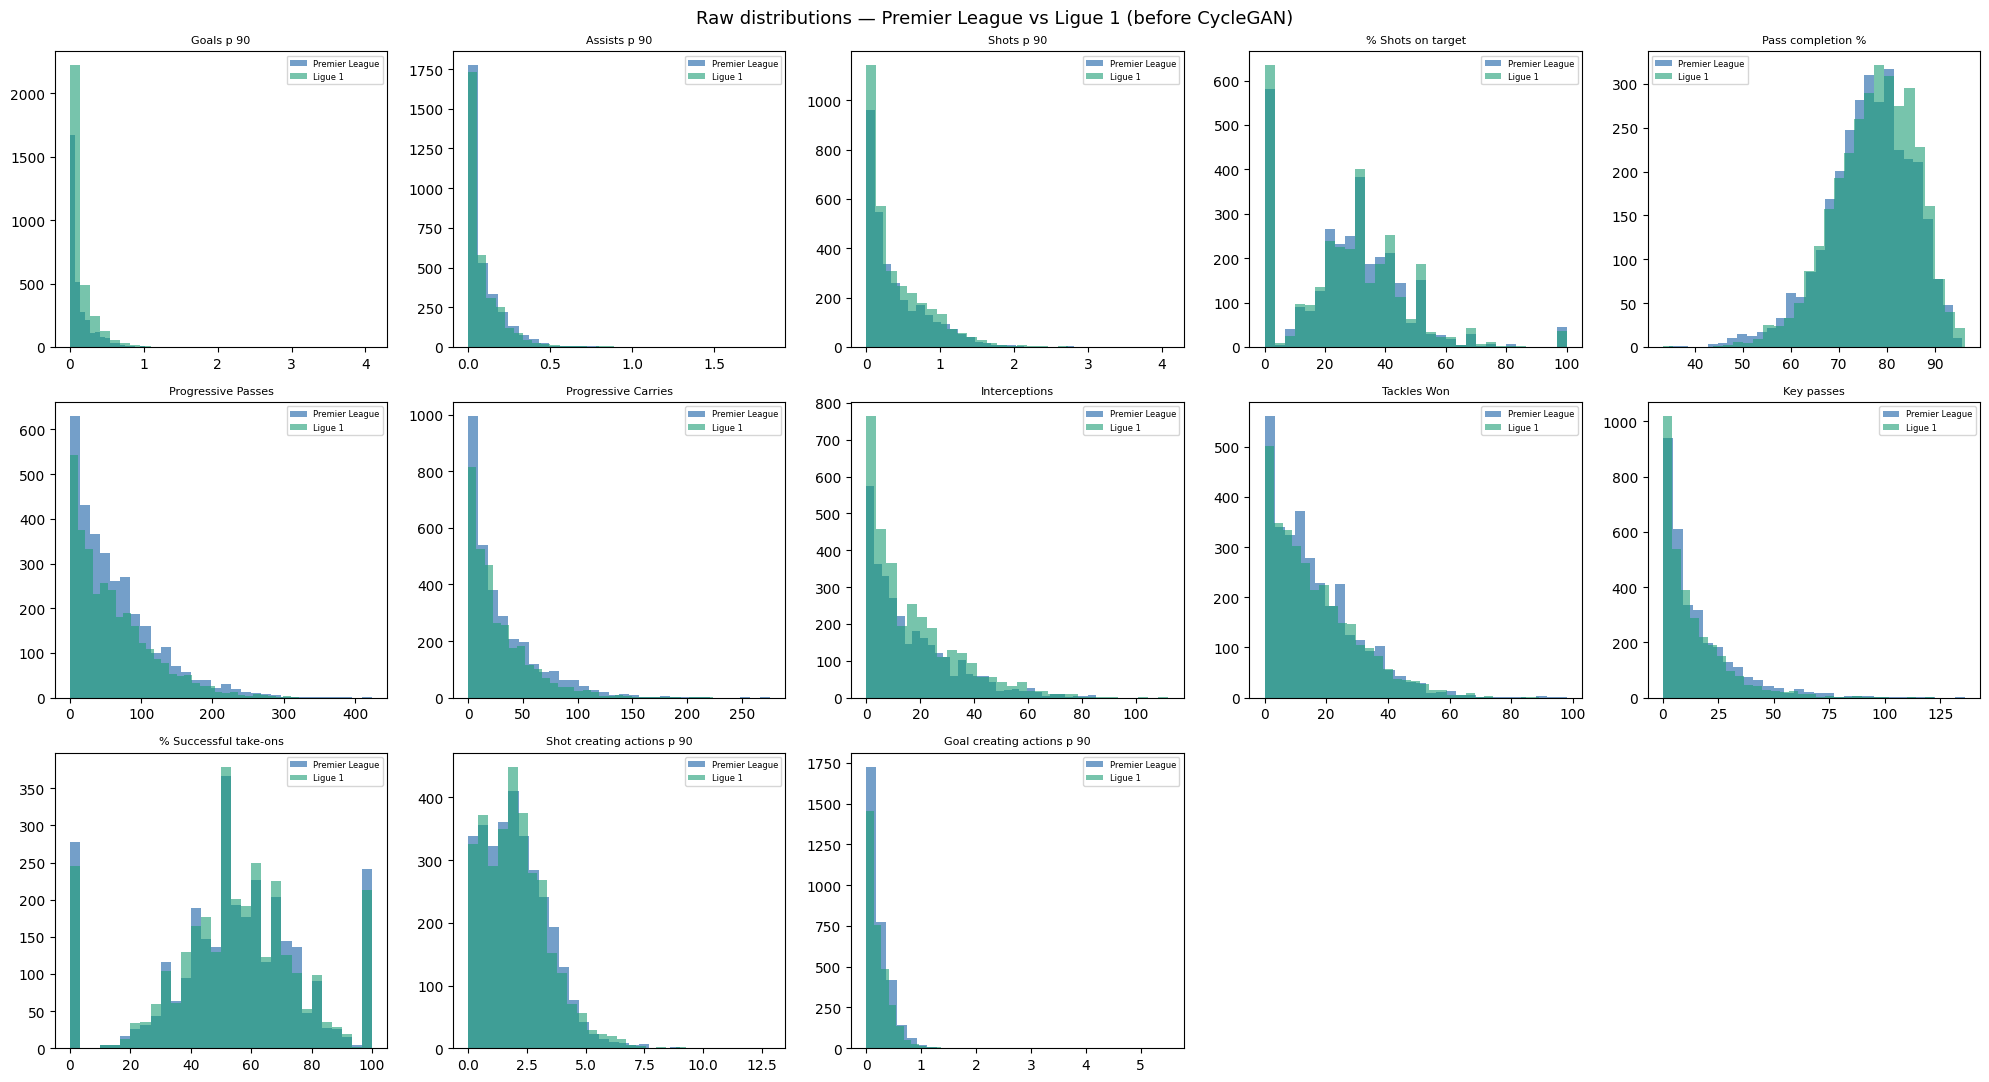

Saved → distributions_before.png


In [12]:
# ── 2G. Visualise raw distributions before translation ────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(pl_df[feat], bins=30, alpha=0.6, label="Premier League", color="#185FA5")
    ax.hist(l1_df[feat], bins=30, alpha=0.6, label="Ligue 1",        color="#1D9E75")
    ax.set_title(feat, fontsize=8)
    ax.legend(fontsize=6)

# Hide unused subplots
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Raw distributions — Premier League vs Ligue 1 (before CycleGAN)", fontsize=13)
plt.tight_layout()
plt.savefig("distributions_before.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → distributions_before.png")

# Build Generator
This code defines the Generator network used in the CycleGAN model. The generator translates a player statistics vector from one league to another using a 4-layer Multi-Layer Perceptron (MLP) with Linear, LayerNorm, and LeakyReLU layers to ensure stable training on tabular data. The output layer has the same dimension as the input, since the model predicts a new set of player statistics. A small test with random input is performed to verify that the generator outputs the correct shape and to display the total number of parameters in the model.

In [13]:
class Generator(nn.Module):
    """
    Translates a player stat vector from one league domain to another.
    Architecture: 4-block MLP with LayerNorm for stable tabular training.
    No activation on output — scaled stats can be negative.
    """
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1 — expand
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),

            # Block 2 — process
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),

            # Block 3 — compress
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.LeakyReLU(0.2),

            # Block 4 — output (same size as input)
            nn.Linear(hidden_dim // 2, input_dim),
        )

    def forward(self, x):
        return self.net(x)

# Sanity check
g_test = Generator(INPUT_DIM)
dummy  = torch.randn(4, INPUT_DIM)
assert g_test(dummy).shape == (4, INPUT_DIM)
total_params = sum(p.numel() for p in g_test.parameters())
print(f"Generator OK — input_dim={INPUT_DIM}, params={total_params:,}")
print(g_test)

Generator OK — input_dim=13, params=105,229
Generator(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=128, out_features=13, bias=True)
  )
)


# Build Discriminator
This code defines the Discriminator network used in the CycleGAN model. The discriminator receives a player statistics vector and predicts whether it comes from the real league distribution or is generated (fake) by the generator. It is built using a Multi-Layer Perceptron (MLP) with Linear layers, LeakyReLU activations, and Dropout to prevent overfitting and keep the discriminator from becoming too strong during training. The final layer outputs a single logit value (without sigmoid), which is later used with a loss function like BCEWithLogitsLoss. A small test is performed to confirm the output shape and print the total number of model parameters.

In [14]:
class Discriminator(nn.Module):
    """
    Classifies whether a stat vector is from the real league distribution
    or generated (fake). Outputs raw logit — no sigmoid.
    Dropout prevents it overpowering the generator too early.
    """
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Block 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Block 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LeakyReLU(0.2),

            # Output — single logit
            nn.Linear(hidden_dim // 4, 1),
        )

    def forward(self, x):
        return self.net(x)

# Sanity check
d_test = Discriminator(INPUT_DIM)
assert d_test(dummy).shape == (4, 1)
total_params = sum(p.numel() for p in d_test.parameters())
print(f"Discriminator OK — input_dim={INPUT_DIM}, params={total_params:,}")
print(d_test)

Discriminator OK — input_dim=13, params=44,801
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


# Loss criteria
This code defines the loss functions used to train the CycleGAN model. The adversarial loss (BCEWithLogitsLoss) trains the generators and discriminators in the GAN framework, where generators try to fool the discriminator and discriminators try to detect fake samples. The cycle consistency loss (L1Loss) ensures that translating data from one league to another and back again reconstructs the original statistics. The identity loss (L1Loss) helps stabilize training by encouraging the generator to leave samples unchanged when they are already in the correct domain. The total generator loss is the combination of adversarial loss, cycle loss (weighted by λ_cycle = 10), and identity loss (weighted by λ_id = 5).

In [15]:
# ── Loss criteria ─────────────────────────────────────────────────
criterion_adv   = nn.BCEWithLogitsLoss()
criterion_cycle = nn.L1Loss()
criterion_id    = nn.L1Loss()

def generator_adv_loss(D, fake):
    """Generator tries to fool D → wants D(fake) = 1."""
    targets = torch.ones(fake.size(0), 1).to(device)
    return criterion_adv(D(fake), targets)

def discriminator_loss(D, real, fake):
    """
    D wants real → 1, fake → 0.
    Multiplied by 0.5 so D updates slower than G.
    """
    loss_real = criterion_adv(D(real),          torch.ones(real.size(0), 1).to(device))
    loss_fake = criterion_adv(D(fake.detach()), torch.zeros(fake.size(0), 1).to(device))
    return (loss_real + loss_fake) * 0.5

def cycle_consistency_loss(real, reconstructed, lam):
    """
    Forward:  A → G_AB(A) → G_BA(G_AB(A)) ≈ A
    Backward: B → G_BA(B) → G_AB(G_BA(B)) ≈ B
    lam = lambda, controls how tight the constraint is.
    """
    return criterion_cycle(reconstructed, real) * lam

def identity_loss(G, real, lam):
    """
    G_AB fed a real PL sample should return it unchanged.
    Stabilises early training — prevents colour/domain shifts
    when not needed.
    """
    return criterion_id(G(real), real) * lam

# ── Visualise the loss concept ────────────────────────────────────
print("Loss breakdown:")
print("  Total G loss = Adversarial + (λ_cycle × Cycle) + (λ_id × Identity)")
print(f"  λ_cycle = 10.0  →  strongly enforces A→B→A reconstruction")
print(f"  λ_id    =  5.0  →  moderately enforces identity mapping")
print()
print("  BCEWithLogitsLoss chosen over plain BCE for numerical stability")
print("  L1Loss chosen for cycle/identity — less blurry than L2")

Loss breakdown:
  Total G loss = Adversarial + (λ_cycle × Cycle) + (λ_id × Identity)
  λ_cycle = 10.0  →  strongly enforces A→B→A reconstruction
  λ_id    =  5.0  →  moderately enforces identity mapping

  BCEWithLogitsLoss chosen over plain BCE for numerical stability
  L1Loss chosen for cycle/identity — less blurry than L2


# Train the Model
This code sets the training configuration and training loop for the CycleGAN model. It defines hyperparameters such as learning rate, batch size, number of epochs, and weights for cycle loss (λ=10) and identity loss (λ=5). Four networks are initialized: two generators for translating player statistics between Ligue 1 and Premier League, and two discriminators that judge whether the statistics are real or generated. The training loop updates generators and discriminators using adversarial, cycle consistency, and identity losses, while learning rate schedulers gradually reduce the learning rate after 150 epochs. Training progress is recorded, and the trained generator models are finally saved for later use.

In [16]:
# ── Hyperparameters ───────────────────────────────────────────────
LAMBDA_CYCLE = 10.0
LAMBDA_ID    = 5.0
LR           = 2e-4
EPOCHS       = 300
BATCH        = 32

# ── Initialise 4 networks ─────────────────────────────────────────
G_AB = Generator(INPUT_DIM).to(device)      # Ligue 1  → Premier League
G_BA = Generator(INPUT_DIM).to(device)      # Premier League → Ligue 1
D_A  = Discriminator(INPUT_DIM).to(device)  # judges Ligue 1 samples
D_B  = Discriminator(INPUT_DIM).to(device)  # judges PL samples

# Separate optimisers for generators and discriminators
opt_G = optim.Adam(
    list(G_AB.parameters()) + list(G_BA.parameters()),
    lr=LR, betas=(0.5, 0.999)
)
opt_D = optim.Adam(
    list(D_A.parameters()) + list(D_B.parameters()),
    lr=LR, betas=(0.5, 0.999)
)

# Decay LR linearly after epoch 150
scheduler_G = optim.lr_scheduler.LambdaLR(
    opt_G, lr_lambda=lambda e: 1.0 - max(0, e - 150) / 150
)
scheduler_D = optim.lr_scheduler.LambdaLR(
    opt_D, lr_lambda=lambda e: 1.0 - max(0, e - 150) / 150
)

# ── Data loaders ──────────────────────────────────────────────────
loader_A = DataLoader(
    TensorDataset(l1_tensor), batch_size=BATCH, shuffle=True, drop_last=True
)
loader_B = DataLoader(
    TensorDataset(pl_tensor), batch_size=BATCH, shuffle=True, drop_last=True
)

# ── Loss history ──────────────────────────────────────────────────
history = {"G_total": [], "D_total": [], "cycle": [], "identity": [], "adv": []}

print(f"Training {EPOCHS} epochs | batch={BATCH} | device={device}\n")
print(f"{'Epoch':>6} | {'G loss':>8} | {'D loss':>8} | {'Cycle':>8} | {'Identity':>8}")
print("─" * 55)

for epoch in range(EPOCHS):
    G_AB.train(); G_BA.train(); D_A.train(); D_B.train()

    batch_G, batch_D, batch_cyc, batch_id, batch_adv = [], [], [], [], []

    for (real_A,), (real_B,) in zip(loader_A, loader_B):

        # ── Generator update ──────────────────────────────────
        opt_G.zero_grad()

        fake_B = G_AB(real_A)          # Ligue 1 → fake PL
        fake_A = G_BA(real_B)          # PL → fake Ligue 1

        # Adversarial — fool both discriminators
        loss_adv = (generator_adv_loss(D_B, fake_B) +
                    generator_adv_loss(D_A, fake_A))

        # Cycle — reconstruct originals
        rec_A   = G_BA(fake_B)
        rec_B   = G_AB(fake_A)
        loss_cyc = (cycle_consistency_loss(real_A, rec_A, LAMBDA_CYCLE) +
                    cycle_consistency_loss(real_B, rec_B, LAMBDA_CYCLE))

        # Identity — don't change what's already correct
        loss_id = (identity_loss(G_AB, real_B, LAMBDA_ID) +
                   identity_loss(G_BA, real_A, LAMBDA_ID))

        loss_G = loss_adv + loss_cyc + loss_id
        loss_G.backward()
        opt_G.step()

        # ── Discriminator update ──────────────────────────────
        opt_D.zero_grad()

        loss_D = (discriminator_loss(D_B, real_B, fake_B) +
                  discriminator_loss(D_A, real_A, fake_A))
        loss_D.backward()
        opt_D.step()

        batch_G.append(loss_G.item())
        batch_D.append(loss_D.item())
        batch_cyc.append(loss_cyc.item())
        batch_id.append(loss_id.item())
        batch_adv.append(loss_adv.item())

    # Step schedulers
    scheduler_G.step()
    scheduler_D.step()

    # Record epoch averages
    history["G_total"].append(np.mean(batch_G))
    history["D_total"].append(np.mean(batch_D))
    history["cycle"].append(np.mean(batch_cyc))
    history["identity"].append(np.mean(batch_id))
    history["adv"].append(np.mean(batch_adv))

    if epoch % 50 == 0 or epoch == EPOCHS - 1:
        print(f"{epoch:>6} | {history['G_total'][-1]:>8.3f} | "
              f"{history['D_total'][-1]:>8.3f} | "
              f"{history['cycle'][-1]:>8.3f} | "
              f"{history['identity'][-1]:>8.3f}")

print("\nTraining complete.")
torch.save(G_AB.state_dict(), "G_AB.pt")
torch.save(G_BA.state_dict(), "G_BA.pt")
print("Saved → G_AB.pt, G_BA.pt")

Training 300 epochs | batch=32 | device=cuda

 Epoch |   G loss |   D loss |    Cycle | Identity
───────────────────────────────────────────────────────
     0 |   12.126 |    1.351 |    7.012 |    3.778
    50 |    2.649 |    1.347 |    0.823 |    0.324
   100 |    2.458 |    1.332 |    0.653 |    0.266
   150 |    2.402 |    1.324 |    0.589 |    0.245
   200 |    2.275 |    1.304 |    0.443 |    0.214
   250 |    2.163 |    1.297 |    0.330 |    0.192
   299 |    2.084 |    1.292 |    0.251 |    0.176

Training complete.
Saved → G_AB.pt, G_BA.pt


# Training loss curves
This code plots the training loss curves of the CycleGAN model. It shows how the generator loss, discriminator loss, and individual loss components (cycle, identity, and adversarial) change across training epochs. These plots help evaluate whether the model is learning properly while translating player statistics between Ligue 1 and Premier League. The figure is saved as training_curves.png for later analysis.

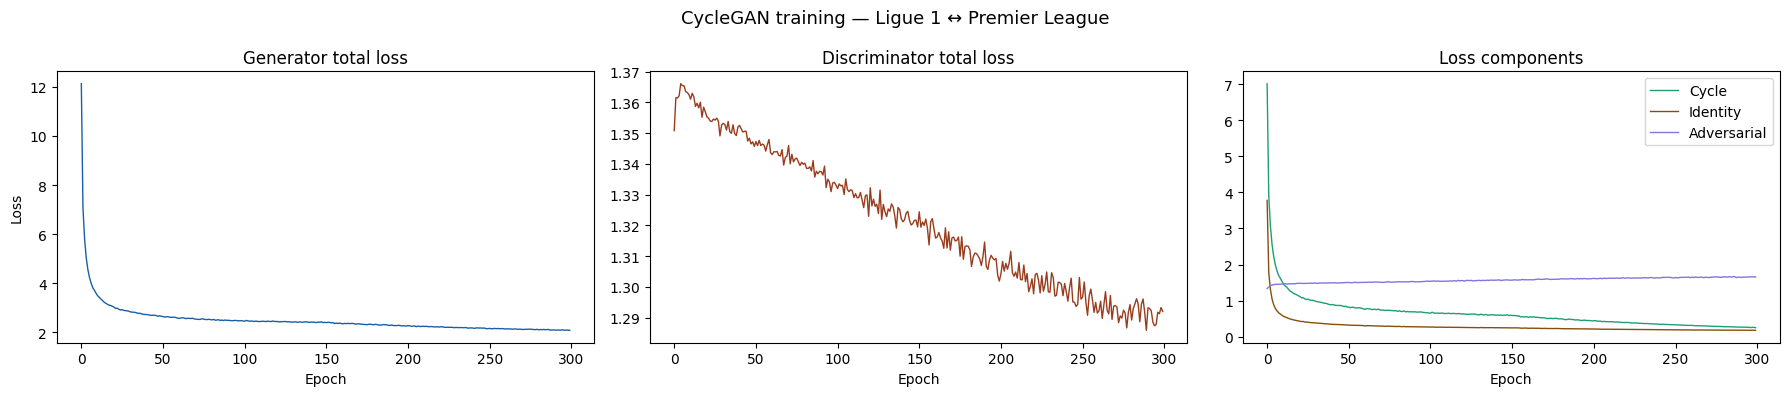

In [17]:
# ── Plot 1: Training loss curves ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["G_total"], color="#185FA5", linewidth=1)
axes[0].set_title("Generator total loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(history["D_total"], color="#993C1D", linewidth=1)
axes[1].set_title("Discriminator total loss")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["cycle"],    color="#1D9E75", linewidth=1, label="Cycle")
axes[2].plot(history["identity"], color="#854F0B", linewidth=1, label="Identity")
axes[2].plot(history["adv"],      color="#7F77DD", linewidth=1, label="Adversarial")
axes[2].set_title("Loss components")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("CycleGAN training — Ligue 1 ↔ Premier League", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Translated distributions vs real
This code evaluates the trained generator by translating Ligue 1 player statistics into Premier League–style statistics using the generator
𝐺
_
𝐴
𝐵
G_AB. The scaled outputs are converted back to the original feature scale using the saved scaler. Histograms are then plotted to compare real Premier League data, real Ligue 1 data, and translated Ligue 1 → Premier League data. If the model works well, the translated distribution should closely match the Premier League distribution rather than the Ligue 1 one. The resulting visualization is saved as distributions_after.png.

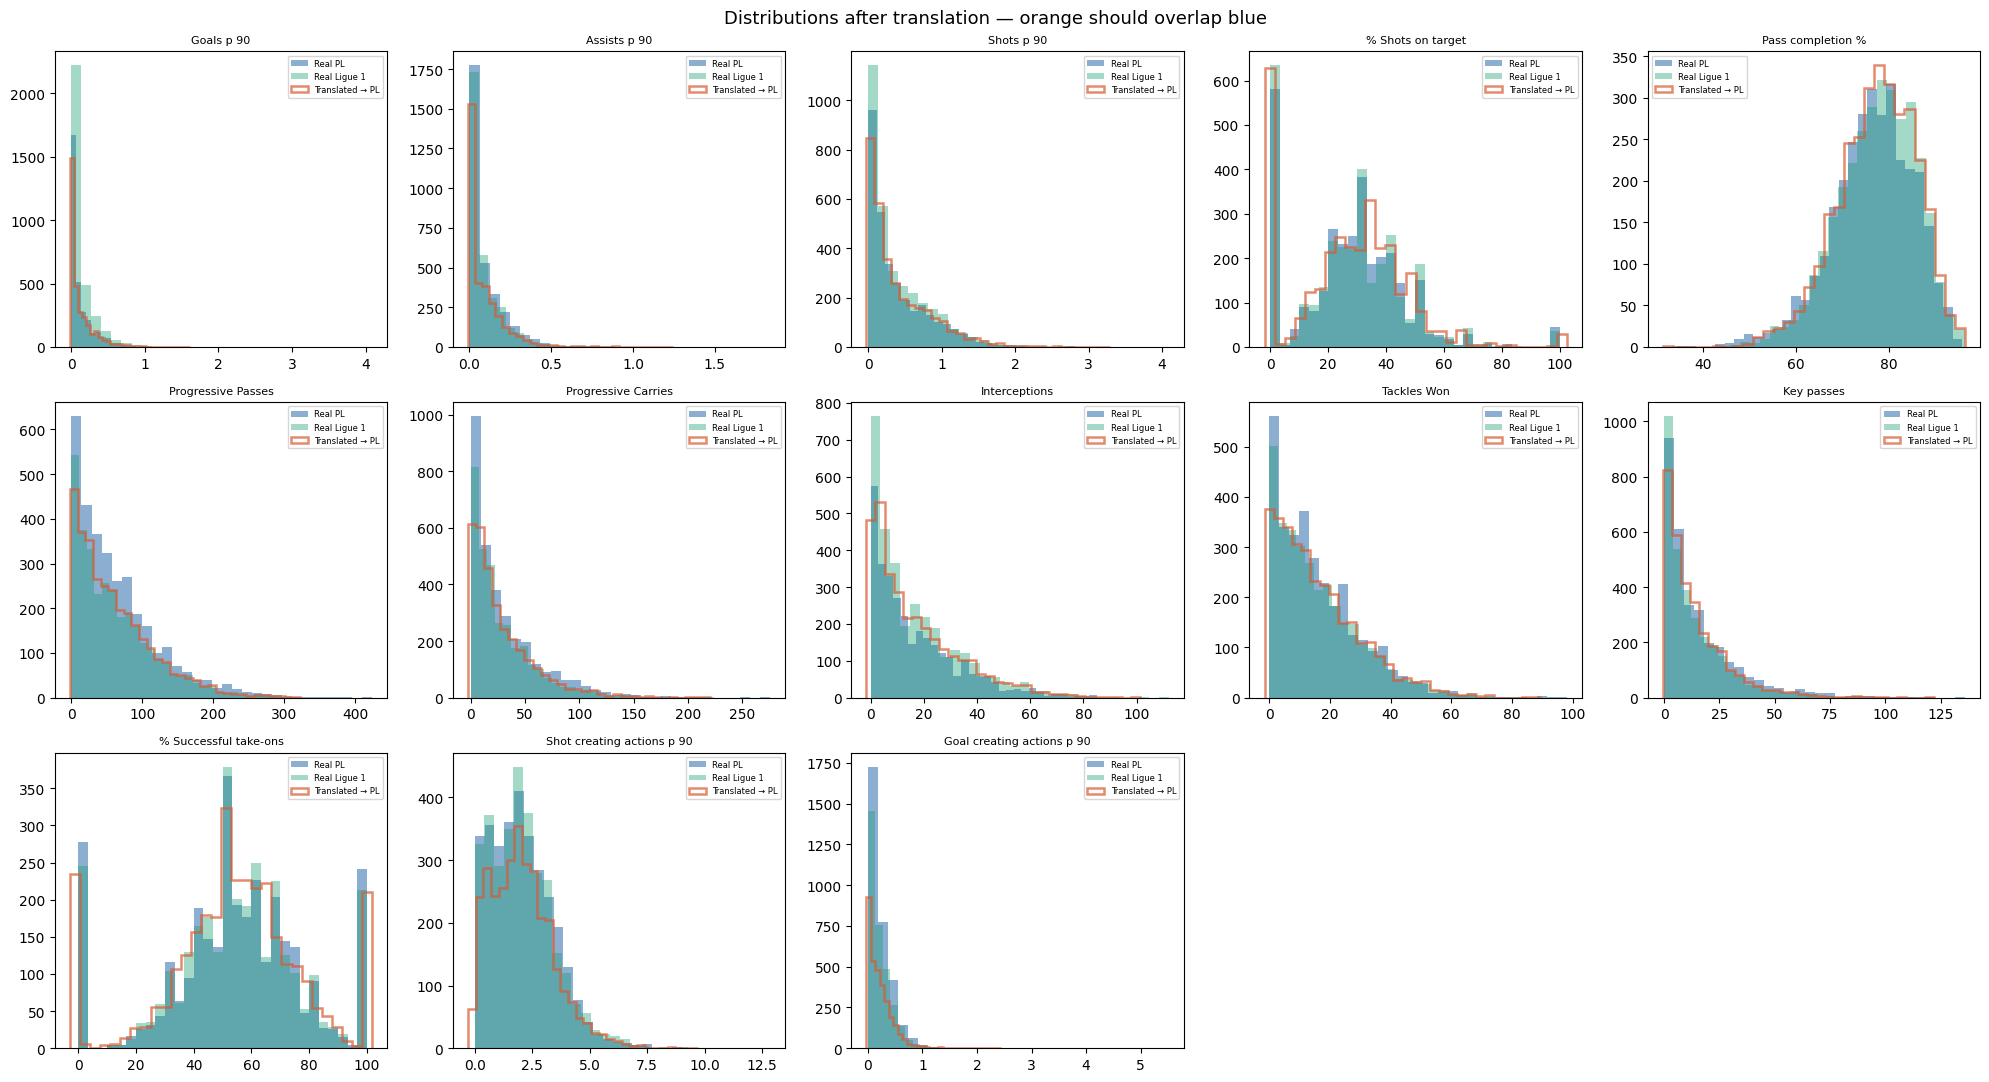

In [18]:
# ── Plot 2: Translated distributions vs real ──────────────────────
G_AB.eval()
with torch.no_grad():
    fake_pl_scaled = G_AB(l1_tensor).cpu().numpy()

fake_pl = scaler.inverse_transform(fake_pl_scaled)
real_pl = scaler.inverse_transform(pl_scaled)
real_l1 = scaler.inverse_transform(l1_scaled)

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(real_pl[:, i], bins=30, alpha=0.5,
            label="Real PL", color="#185FA5")
    ax.hist(real_l1[:, i], bins=30, alpha=0.4,
            label="Real Ligue 1", color="#1D9E75")
    ax.hist(fake_pl[:, i], bins=30, alpha=0.7,
            label="Translated → PL", color="#D85A30",
            histtype="step", linewidth=1.8)
    ax.set_title(feat, fontsize=8)
    ax.legend(fontsize=6)

for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions after translation — orange should overlap blue", fontsize=13)
plt.tight_layout()
plt.savefig("distributions_after.png", dpi=150, bbox_inches="tight")
plt.show()

# KS test bar chart
This code performs a Kolmogorov–Smirnov (KS) test to compare the statistical similarity between the translated player statistics and the real Premier League data. For each feature, the KS statistic and p-value are calculated between the translated Ligue 1 → Premier League data and the real Premier League distribution. The results are visualized in a horizontal bar chart where lower KS values indicate more similar distributions. Features with p > 0.05 (green) suggest the translated distribution is statistically similar to the real data, while p ≤ 0.05 (red) indicates remaining differences. The chart is saved as ks_test.png, and a table of results is printed for detailed analysis.

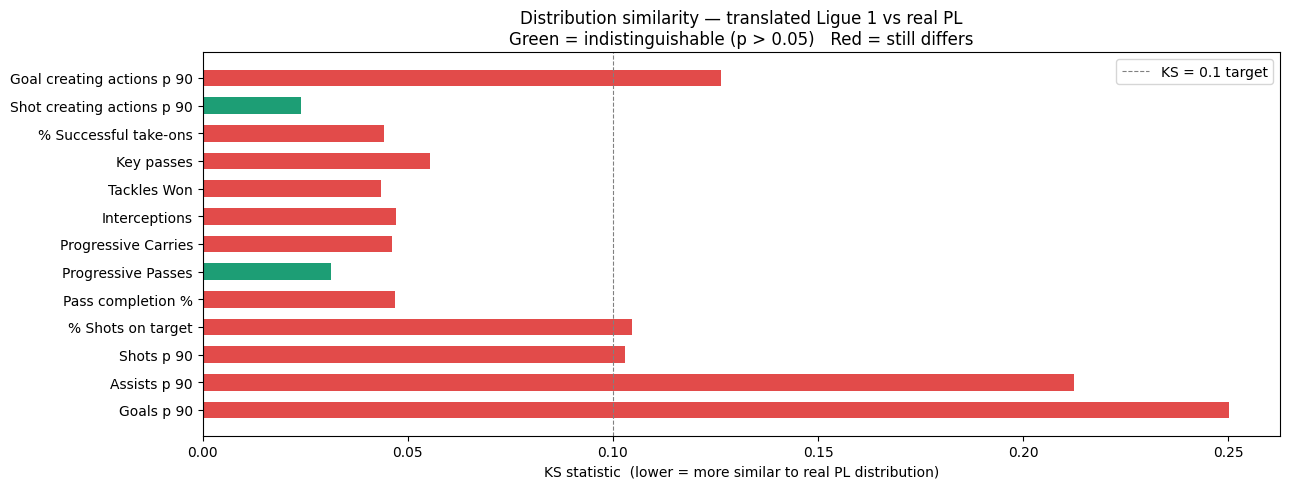


Feature                                 KS    p-val  Pass?
────────────────────────────────────────────────────────────
Goals p 90                           0.250    0.000     NO
Assists p 90                         0.212    0.000     NO
Shots p 90                           0.103    0.000     NO
% Shots on target                    0.105    0.000     NO
Pass completion %                    0.047    0.002     NO
Progressive Passes                   0.031    0.085    YES
Progressive Carries                  0.046    0.002     NO
Interceptions                        0.047    0.002     NO
Tackles Won                          0.043    0.005     NO
Key passes                           0.055    0.000     NO
% Successful take-ons                0.044    0.004     NO
Shot creating actions p 90           0.024    0.312    YES
Goal creating actions p 90           0.126    0.000     NO


In [19]:
# ── Plot 3: KS test bar chart ─────────────────────────────────────
ks_stats, ks_pvals = [], []
for i in range(len(FEATURES)):
    s, p = ks_2samp(real_pl[:, i], fake_pl[:, i])
    ks_stats.append(s); ks_pvals.append(p)

colors = ["#1D9E75" if p > 0.05 else "#E24B4A" for p in ks_pvals]

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(FEATURES, ks_stats, color=colors, height=0.6)
ax.axvline(0.1, color="gray", linestyle="--", linewidth=0.8, label="KS = 0.1 target")
ax.set_xlabel("KS statistic  (lower = more similar to real PL distribution)")
ax.set_title("Distribution similarity — translated Ligue 1 vs real PL\n"
             "Green = indistinguishable (p > 0.05)   Red = still differs")
ax.legend()
plt.tight_layout()
plt.savefig("ks_test.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Feature':<35} {'KS':>6} {'p-val':>8} {'Pass?':>6}")
print("─" * 60)
for feat, ks, pv in zip(FEATURES, ks_stats, ks_pvals):
    print(f"{feat:<35} {ks:>6.3f} {pv:>8.3f} {'YES' if pv > 0.05 else 'NO':>6}")

# PCA
This code uses Principal Component Analysis (PCA) to visualize how well the translated player statistics align with real league data. The high-dimensional feature data is reduced to two principal components for visualization. The first plot shows the original distributions of players from the Premier League and Ligue 1 before translation. The second plot compares real Premier League data with the translated Ligue 1 → Premier League data. If the model works well, the translated points should overlap or mix with the real Premier League cluster, indicating successful domain translation. The plot is saved as pca_alignment.png.

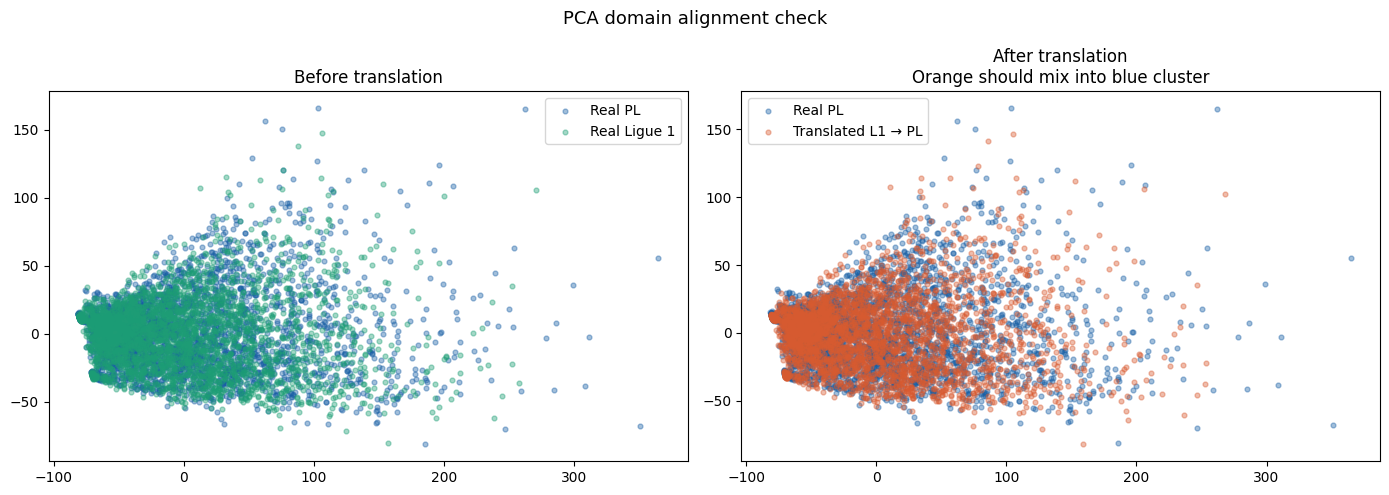

In [20]:
# ── Plot 4: PCA alignment ─────────────────────────────────────────
pca = PCA(n_components=2)
pca.fit(np.vstack([real_pl, real_l1]))

proj_real_pl = pca.transform(real_pl)
proj_real_l1 = pca.transform(real_l1)
proj_fake_pl = pca.transform(fake_pl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(proj_real_pl[:, 0], proj_real_pl[:, 1],
                alpha=0.4, s=12, color="#185FA5", label="Real PL")
axes[0].scatter(proj_real_l1[:, 0], proj_real_l1[:, 1],
                alpha=0.4, s=12, color="#1D9E75", label="Real Ligue 1")
axes[0].set_title("Before translation"); axes[0].legend()

axes[1].scatter(proj_real_pl[:, 0], proj_real_pl[:, 1],
                alpha=0.4, s=12, color="#185FA5", label="Real PL")
axes[1].scatter(proj_fake_pl[:, 0], proj_fake_pl[:, 1],
                alpha=0.4, s=12, color="#D85A30", label="Translated L1 → PL")
axes[1].set_title("After translation\nOrange should mix into blue cluster")
axes[1].legend()

plt.suptitle("PCA domain alignment check", fontsize=13)
plt.tight_layout()
plt.savefig("pca_alignment.png", dpi=150, bbox_inches="tight")
plt.show()

# Translate every Ligue 1 player and save to CSV
This code uses the trained generator to translate all player statistics from Ligue 1 to projected Premier League statistics. The generated values are converted back to the original scale using the saved scaler. A results table is created containing each player's original Ligue 1 stats, the projected Premier League stats, and the difference between them (delta). The final projections are saved as scouting_projections.csv, which can be used for player scouting and transfer analysis.

In [21]:
# ── Translate every Ligue 1 player and save to CSV ────────────────
G_AB.eval()
with torch.no_grad():
    all_translated = G_AB(l1_tensor).cpu().numpy()

all_projected = scaler.inverse_transform(all_translated)

results = l1_names.copy()
for i, feat in enumerate(FEATURES):
    results[f"L1_{feat}"]        = l1_df[feat].values
    results[f"PL_proj_{feat}"]   = all_projected[:, i]
    results[f"delta_{feat}"]     = all_projected[:, i] - l1_df[feat].values

results.to_csv("scouting_projections.csv", index=False)
print("Saved → scouting_projections.csv")
print(results.head(10).to_string())

Saved → scouting_projections.csv
                   player        squad     season  L1_Goals p 90  PL_proj_Goals p 90  delta_Goals p 90  L1_Assists p 90  PL_proj_Assists p 90  delta_Assists p 90  L1_Shots p 90  PL_proj_Shots p 90  delta_Shots p 90  L1_% Shots on target  PL_proj_% Shots on target  delta_% Shots on target  L1_Pass completion %  PL_proj_Pass completion %  delta_Pass completion %  L1_Progressive Passes  PL_proj_Progressive Passes  delta_Progressive Passes  L1_Progressive Carries  PL_proj_Progressive Carries  delta_Progressive Carries  L1_Interceptions  PL_proj_Interceptions  delta_Interceptions  L1_Tackles Won  PL_proj_Tackles Won  delta_Tackles Won  L1_Key passes  PL_proj_Key passes  delta_Key passes  L1_% Successful take-ons  PL_proj_% Successful take-ons  delta_% Successful take-ons  L1_Shot creating actions p 90  PL_proj_Shot creating actions p 90  delta_Shot creating actions p 90  L1_Goal creating actions p 90  PL_proj_Goal creating actions p 90  delta_Goal creating a

# Show top 10 Ligue 1 players projected to score most goals in PL
This code identifies the top 10 players from Ligue 1 who are projected to score the most goals per 90 minutes in the Premier League based on the CycleGAN translation. The results are sorted by the projected PL goals per 90 value, and the table shows each player's name, team, season, original Ligue 1 goals per 90, projected Premier League goals per 90, and the difference (delta). This helps highlight players who might perform strongly if they moved to the Premier League.

In [22]:
# ── Show top 10 Ligue 1 players projected to score most goals in PL ─
top10 = (results
         .sort_values("PL_proj_Goals p 90", ascending=False)
         .head(10)[["player", "squad", "season",
                     "L1_Goals p 90", "PL_proj_Goals p 90", "delta_Goals p 90"]]
         .round(3))

print("\nTop 10 Ligue 1 players projected by PL goals/90:\n")
print(top10.to_string(index=False))


Top 10 Ligue 1 players projected by PL goals/90:

           player          squad    season  L1_Goals p 90  PL_proj_Goals p 90  delta_Goals p 90
Souleymane Camara    Montpellier 2018-2019           1.97               1.612            -0.358
   Lamine Ghezali Saint-Ãtienne 2018-2019           2.05               1.605            -0.445
     Nolan Mbemba       Le Havre 2023-2024           4.09               1.504            -2.586
  Ignatius Ganago           Nice 2017-2018           1.30               1.296            -0.004
     Moussa KonÃ©         NÃ®mes 2019-2020           1.29               1.279            -0.011
   Kylian MbappÃ©      Paris S-G 2018-2019           1.27               1.278             0.008
  Issouf Sissokho       Bordeaux 2020-2021           1.15               1.124            -0.026
   Kylian MbappÃ©      Paris S-G 2023-2024           1.13               1.123            -0.007
   Kylian MbappÃ©      Paris S-G 2019-2020           1.07               1.075        

# Download
This code downloads all the important models, results, and visualizations generated during the project. It includes the trained generator models, the saved scaler, the player projection CSV file, and all evaluation plots such as training curves, distribution comparisons, KS test results, and PCA alignment. Downloading these files allows the results of the CycleGAN analysis between Ligue 1 and Premier League to be saved and used outside the notebook.

In [23]:
# ── Download everything ───────────────────────────────────────────
for f in ["G_AB.pt", "G_BA.pt", "scaler.pkl",
          "scouting_projections.csv",
          "training_curves.png",
          "distributions_before.png",
          "distributions_after.png",
          "ks_test.png",
          "pca_alignment.png"]:
    files.download(f)
    print(f"Downloaded → {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → G_AB.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded → ks_test.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → pca_alignment.png
